In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [154]:
spf = pd.read_excel(r"C:\Users\zheng\Downloads\SPFmicrodata (1).xlsx", sheet_name = "PRUNEMP")

C:\Users\zheng\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [155]:
spf

,YEAR,QUARTER,ID,INDUSTRY,PRUNEMP1,PRUNEMP2,PRUNEMP3,PRUNEMP4,PRUNEMP5,PRUNEMP6,...,PRUNEMP31,PRUNEMP32,PRUNEMP33,PRUNEMP34,PRUNEMP35,PRUNEMP36,PRUNEMP37,PRUNEMP38,PRUNEMP39,PRUNEMP40
0,1968,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1968,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9173,2025,4,602,1.0,0.0,0.0,0.0,0.0,0.0000,10.0000,...,1.0000,0.5000,1.0000,2.5000,5.0000,10.0000,15.0000,25.0000,25.0000,15.0000
9174,2025,4,603,2.0,0.0,0.0,0.0,0.0,2.0000,8.0000,...,0.0000,0.0000,0.0000,0.0000,5.0000,11.0000,45.0000,34.0000,5.0000,0.0000
9175,2025,4,607,2.0,0.0,0.0,0.0,0.0,0.0486,5.5142,...,0.4701,3.4846,7.1765,13.9706,9.8367,11.4126,12.2532,12.1743,11.1935,18.0279
9176,2025,4,608,2.0,0.0,0.0,1.0,4.0,6.0000,12.0000,...,0.0000,0.0000,1.0000,4.0000,6.0000,13.0000,31.0000,37.0000,6.0000,2.0000


In [156]:
unemp_rate = pd.read_csv(r"C:\Users\zheng\Downloads\UNRATE (1).csv")
unemp_rate['DATE'] = pd.to_datetime(unemp_rate['observation_date'])
unemp_rate['YEAR'] = unemp_rate['DATE'].dt.year #date time 

In [157]:
unemp_rate

,observation_date,UNRATE,DATE,YEAR
0,2009-01-01,9.3,2009-01-01,2009
1,2010-01-01,9.6,2010-01-01,2010
2,2011-01-01,8.9,2011-01-01,2011
3,2012-01-01,8.1,2012-01-01,2012
4,2013-01-01,7.4,2013-01-01,2013
5,2014-01-01,6.2,2014-01-01,2014
6,2015-01-01,5.3,2015-01-01,2015
7,2016-01-01,4.9,2016-01-01,2016
8,2017-01-01,4.4,2017-01-01,2017
9,2018-01-01,3.9,2018-01-01,2018


In [158]:
#Dropping columns 1-10 and 21-40 
spf1 = spf.drop(columns = ['PRUNEMP1', 'PRUNEMP2', 'PRUNEMP3',
       'PRUNEMP4', 'PRUNEMP5', 'PRUNEMP6', 'PRUNEMP7', 'PRUNEMP8', 'PRUNEMP9',
       'PRUNEMP10','PRUNEMP21', 'PRUNEMP22', 'PRUNEMP23', 'PRUNEMP24',
       'PRUNEMP25', 'PRUNEMP26', 'PRUNEMP27', 'PRUNEMP28', 'PRUNEMP29',
       'PRUNEMP30', 'PRUNEMP31', 'PRUNEMP32', 'PRUNEMP33', 'PRUNEMP34',
       'PRUNEMP35', 'PRUNEMP36', 'PRUNEMP37', 'PRUNEMP38', 'PRUNEMP39',
       'PRUNEMP40'])

In [159]:
#Check for probability sums to 100

#creating a list of the columns that I want to add up 
columns = ['PRUNEMP20','PRUNEMP19','PRUNEMP18',
           'PRUNEMP17','PRUNEMP16','PRUNEMP15',
           'PRUNEMP14','PRUNEMP13','PRUNEMP12','PRUNEMP11']
#keeps only the rows of Prenump that == 100
def check_prob(row):
    total = row[columns].sum() #adds across the row 
    if round(total) == 100:
        return True #keep this row
    else:
        return False #drop this
spf1 = spf1[spf1.apply(check_prob, axis=1)]  #check horizontally, and only returns True Columns flase are removed  

In [160]:
unemp_dict = dict(zip(unemp_rate['YEAR'],unemp_rate['UNRATE']))
#pairing annual unemp rate and pairing it with the year it corresponds with
spf1['Next_Year']=spf1["YEAR"] + 1 
#forecasts made are always for next year
spf1['real_unemp'] = spf1['Next_Year'].map(unemp_dict)
#assigns next years unemployment to each forecast

In [161]:
#Cleaning Data
#Creating Date Column from Year and Quarter
spf1["Date"] = pd.PeriodIndex.from_fields(year=spf1['YEAR'],quarter=spf1['QUARTER'],freq='Q') #There is no Date column so we set year and Quarter as the Date

#MultiIndex
spf1 = spf1.set_index(["ID","Date"]).sort_index()

#Drop NA
spf1 = spf1.dropna(subset=['real_unemp']) #drop any N/A unemp rates 

In [162]:
#Dropping 15 investors
# I don't know how to access the MultiIndex

#reset index so I can access ID column
spf1 = spf1.reset_index()

#Count how many times each forecaster appears in the dataset
ID_count = spf1["ID"].value_counts()

#keeps an index of all the IDs that appear in 15 or more quarters
drop_ID = ID_count[ID_count < 15].index

#drop the rows that appear in drop_ID index as those have investors that appear < 15 times
for i in drop_ID:
    spf1 = spf1[spf1["ID"] != i]

#revert back to MultiIndex
spf1 = spf1.set_index(["ID","Date"]).sort_index()


In [168]:
spf1

YEAR  QUARTER  INDUSTRY  PRUNEMP11  PRUNEMP12  PRUNEMP13  \
ID  Date                                                               
407 2009Q2  2009        2       2.0        0.0        0.0        5.0   
    2009Q3  2009        3       2.0        0.0        0.0        0.0   
    2009Q4  2009        4       2.0        0.0        5.0       85.0   
    2010Q1  2010        1       2.0        0.0        0.0        0.0   
    2010Q2  2010        2       2.0        0.0        0.0        0.0   
...          ...      ...       ...        ...        ...        ...   
588 2022Q4  2022        4       1.0        0.0        0.0        0.0   
    2023Q1  2023        1       1.0        0.0        0.0        0.0   
    2023Q2  2023        2       1.0        0.0        0.0        0.0   
    2023Q3  2023        3       1.0        0.0        0.0        0.0   
    2023Q4  2023        4       1.0        0.0        0.0        0.0   

            PRUNEMP14  PRUNEMP15  PRUNEMP16  PRUNEMP17  PRUNEMP18  PRUNEMP19  \
ID  Date                                                                       
407 2009Q2       70.0       15.0       10.0        0.0        0.0        0.0   
    2009Q3        5.0       70.0       25.0        0.0        0.0        0.0   
    2009Q4       10.0        0.0        0.0        0.0        0.0        0.0   
    2010Q1        0.0       40.0       60.0        0.0        0.0        0.0   
    2010Q2       15.0       20.0       60.0        5.0        0.0        0.0   
...               ...        ...        ...        ...        ...        ...   
588 2022Q4        0.0        0.0       20.0       55.0       20.0        5.0   
    2023Q1        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q2        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q3        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q4        0.0        0.0        0.0       15.0       55.0       25.0   

            PRUNEMP20  Next_Year  real_unemp  
ID  Date                                      
407 2009Q2        0.0       2010         9.6  
    2009Q3        0.0       2010         9.6  
    2009Q4        0.0       2010         9.6  
    2010Q1        0.0       2011         8.9  
    2010Q2        0.0       2011         8.9  
...               ...        ...         ...  
588 2022Q4        0.0       2023         3.6  
    2023Q1        5.0       2024         4.0  
    2023Q2        5.0       2024         4.0  
    2023Q3        5.0       2024         4.0  
    2023Q4        5.0       2024         4.0  

[1736 rows x 15 columns]

In [169]:
unemp_intervals = {

    "2009-2013": [
        (0.0, 6.0),
        (6.0, 6.9),
        (7.0, 7.4),
        (7.5, 7.9),
        (8.0, 8.4),
        (8.5, 8.9),
        (9.0, 9.4),
        (9.5, 9.9),
        (10.0,10.9),
        (11.0, 100)
    ],

    "2014-2020": [
        (0.0, 4.0),
        (4.0, 4.9),
        (5.0, 5.4),
        (5.5, 5.9),
        (6.0, 6.4),
        (6.5, 6.9),
        (7.0, 7.4),
        (7.5, 7.9),
        (8.0, 8.9),
        (9.0, 100)
    ],

    "2020-2024": [
        (0.0, 3.0),
        (3.0, 3.9),
        (4.0, 4.9),
        (5.0, 5.9),
        (6.0, 6.9),
        (7.0, 7.9),
        (8.0, 9.9),
        (10.0, 11.9),
        (12.0, 14.9),
        (15.0, 100)
    ],

    "2024-present": [
        (0.0, 3.1),
        (3.1, 3.6),
        (3.7, 4.2),
        (4.3, 4.8),
        (4.9, 5.4),
        (5.5, 6.0),
        (6.1, 7.1),
        (7.2, 8.2),
        (8.3, 9.8),
        (9.9, 100)
    ],
}


In [176]:
# Choose which interval set to use based on the forecasted year
def get_year(next_year):
    if next_year <= 2013:
        return unemp_intervals["2009-2013"]
    elif next_year <= 2020:
        return unemp_intervals["2014-2020"]
    elif next_year <= 2024:
        return unemp_intervals["2020-2024"]
    else:
        return unemp_intervals["2024-present"]


In [178]:
def compute_cdf(intervals,probs,real_unemp,N = 1000):
    rng = np.random.default_rng() #random number generator
    
    #keeps score of how many values were less than real unemployment rate
    count = 0 
    for i in range(N):
        #picks one of the 10 bins based on probability
        interval_idx = rng.choice(len(intervals),p = probs) #choose which interval to sample using probability
        
        lower,upper = intervals[interval_idx] #find the real upper/lower bin ranges
    
        sample_value = rng.uniform(lower, upper)#pick a random number from the bin
        
        if sample_value <= real_unemp: #check if its less than or equal to real unemployment
            count += 1 #add 1 if it is less than or equal to the real unemployment rate
    return count/N #estimated CDF converting count to a fraction


In [180]:
cdf_values = [] #store CDF values we calculate for each row

spf1 = spf1.copy() #copy so I don't mess with original

N = 1000 #num of simulations ran 

for index in spf1.index: #loop through every row
    date = index[1] #grabbing date part of the (ID,Date)
    forecast_year = date.year + 1 #we use next year so +1
   
    if forecast_year not in unemp_dict: #no data then skip
        cdf_values.append(None)
        continue
    #real unemp for next year
    real_unemp = unemp_dict[forecast_year]

    #grab correct interval range based on which year the forecast belongs to
    intervals = get_year(forecast_year)

    #grab all 10 probabilities for the row(PRUNEMP11-20)
    probability = spf1.loc[index,columns].values
    probs = probability/probability.sum()

    #call function
    cdf = compute_cdf(intervals,probs,real_unemp)
    cdf_values.append(cdf) #store to list

spf1.loc[:,'CDF'] = cdf_values #add CDF values as new column


In [181]:
spf1

YEAR  QUARTER  INDUSTRY  PRUNEMP11  PRUNEMP12  PRUNEMP13  \
ID  Date                                                               
407 2009Q2  2009        2       2.0        0.0        0.0        5.0   
    2009Q3  2009        3       2.0        0.0        0.0        0.0   
    2009Q4  2009        4       2.0        0.0        5.0       85.0   
    2010Q1  2010        1       2.0        0.0        0.0        0.0   
    2010Q2  2010        2       2.0        0.0        0.0        0.0   
...          ...      ...       ...        ...        ...        ...   
588 2022Q4  2022        4       1.0        0.0        0.0        0.0   
    2023Q1  2023        1       1.0        0.0        0.0        0.0   
    2023Q2  2023        2       1.0        0.0        0.0        0.0   
    2023Q3  2023        3       1.0        0.0        0.0        0.0   
    2023Q4  2023        4       1.0        0.0        0.0        0.0   

            PRUNEMP14  PRUNEMP15  PRUNEMP16  PRUNEMP17  PRUNEMP18  PRUNEMP19  \
ID  Date                                                                       
407 2009Q2       70.0       15.0       10.0        0.0        0.0        0.0   
    2009Q3        5.0       70.0       25.0        0.0        0.0        0.0   
    2009Q4       10.0        0.0        0.0        0.0        0.0        0.0   
    2010Q1        0.0       40.0       60.0        0.0        0.0        0.0   
    2010Q2       15.0       20.0       60.0        5.0        0.0        0.0   
...               ...        ...        ...        ...        ...        ...   
588 2022Q4        0.0        0.0       20.0       55.0       20.0        5.0   
    2023Q1        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q2        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q3        0.0        0.0        0.0       15.0       55.0       25.0   
    2023Q4        0.0        0.0        0.0       15.0       55.0       25.0   

            PRUNEMP20  Next_Year  real_unemp    CDF  
ID  Date                                             
407 2009Q2        0.0       2010         9.6  0.960  
    2009Q3        0.0       2010         9.6  1.000  
    2009Q4        0.0       2010         9.6  0.319  
    2010Q1        0.0       2011         8.9  1.000  
    2010Q2        0.0       2011         8.9  0.846  
...               ...        ...         ...    ...  
588 2022Q4        0.0       2023         3.6  0.032  
    2023Q1        5.0       2024         4.0  0.288  
    2023Q2        5.0       2024         4.0  0.267  
    2023Q3        5.0       2024         4.0  0.276  
    2023Q4        5.0       2024         4.0  0.305  

[1736 rows x 16 columns]

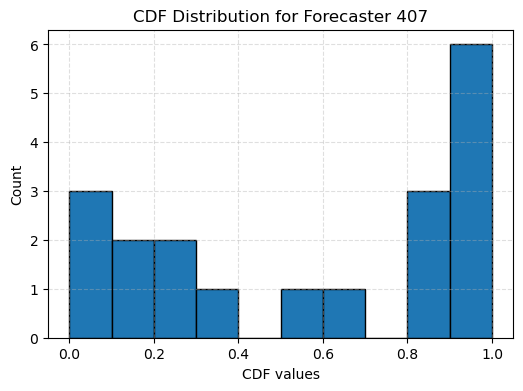

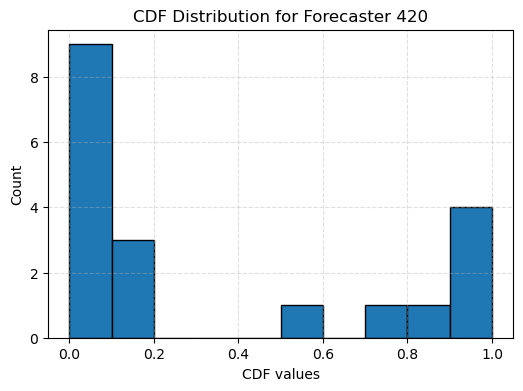

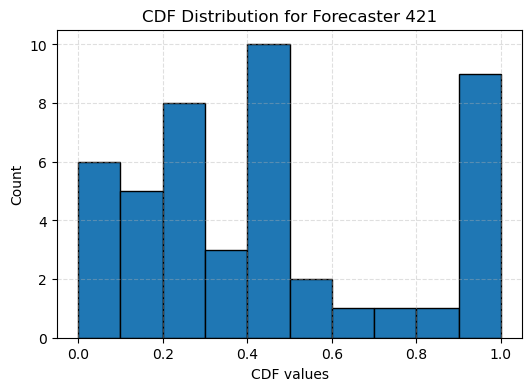

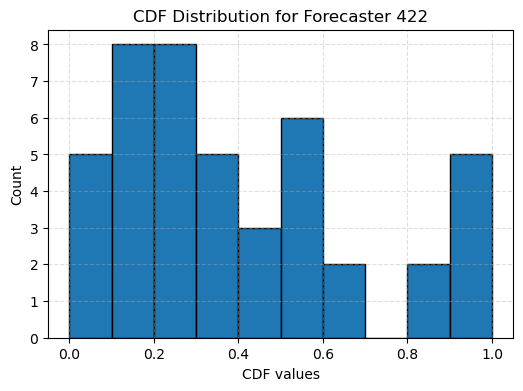

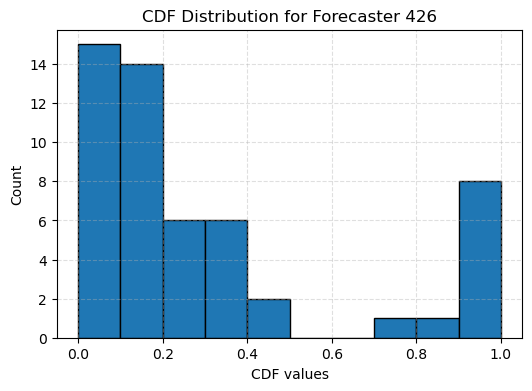

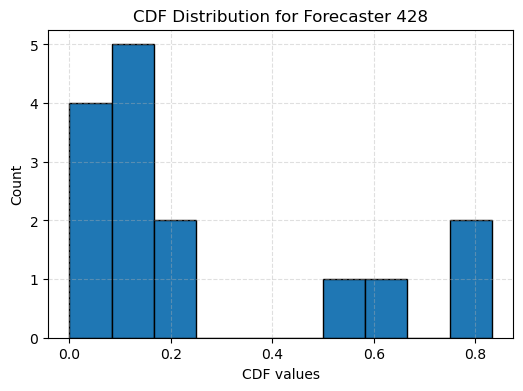

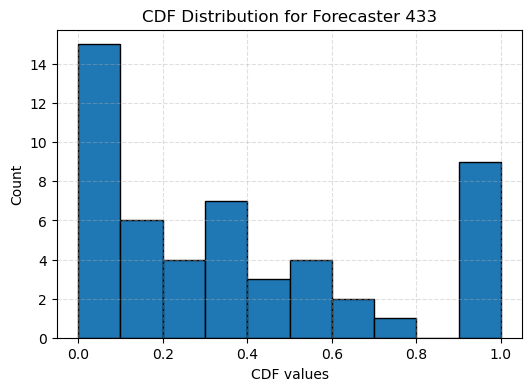

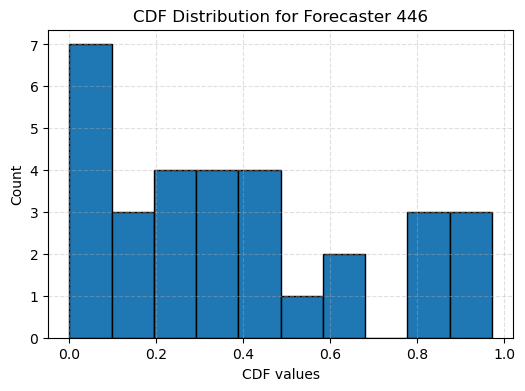

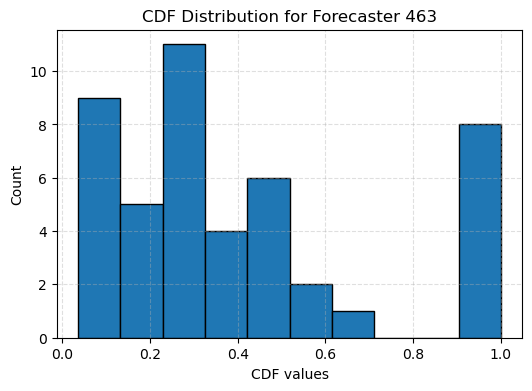

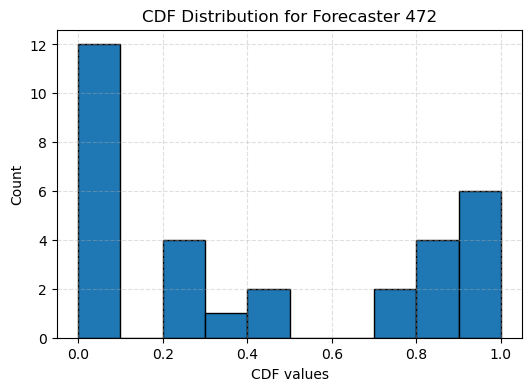

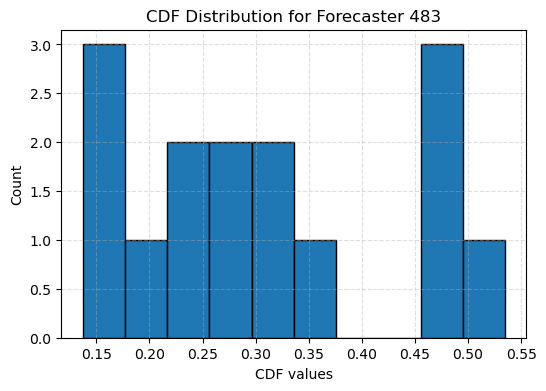

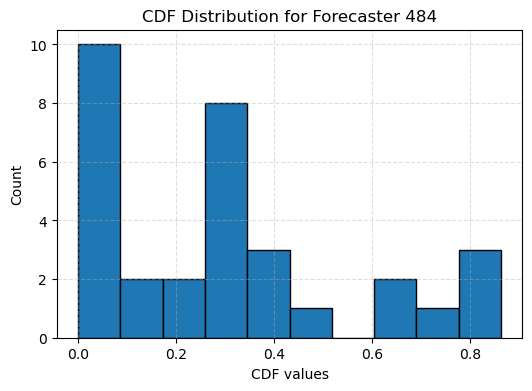

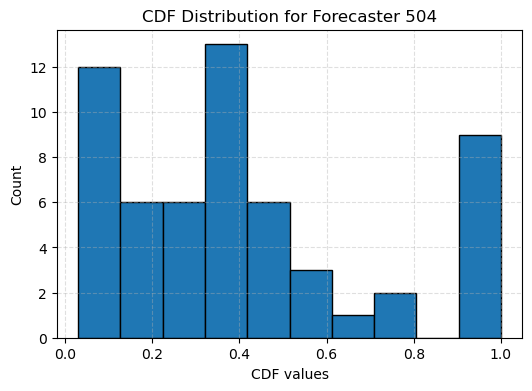

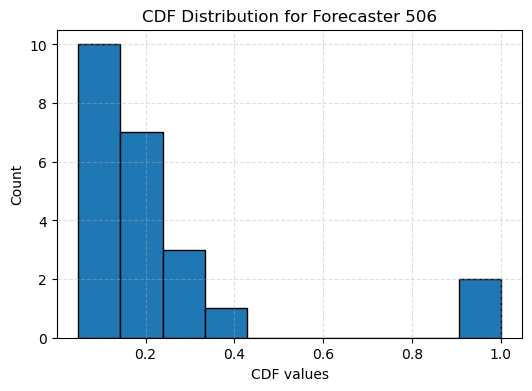

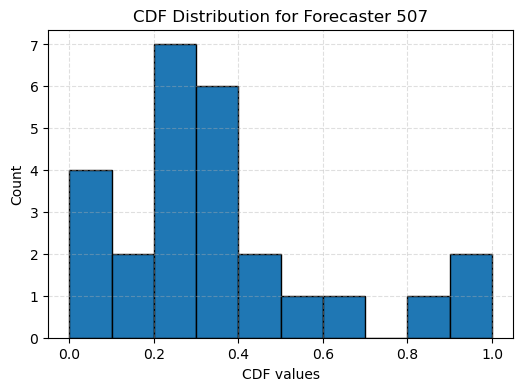

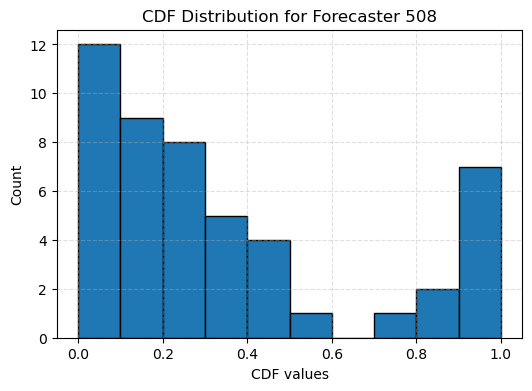

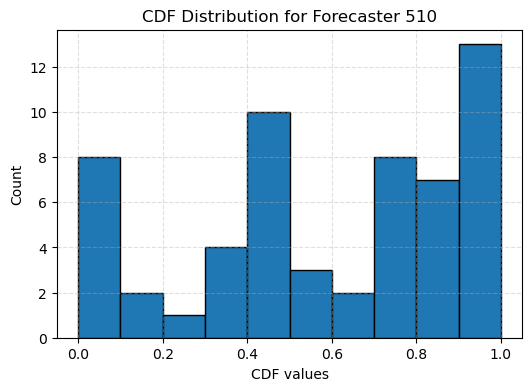

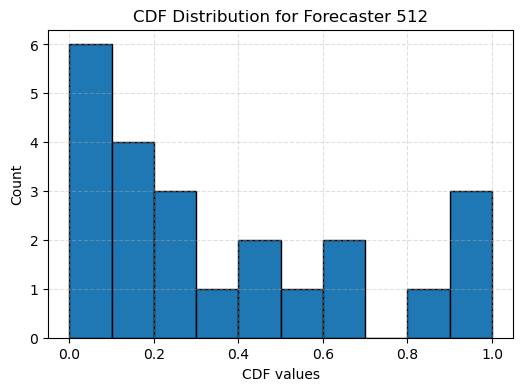

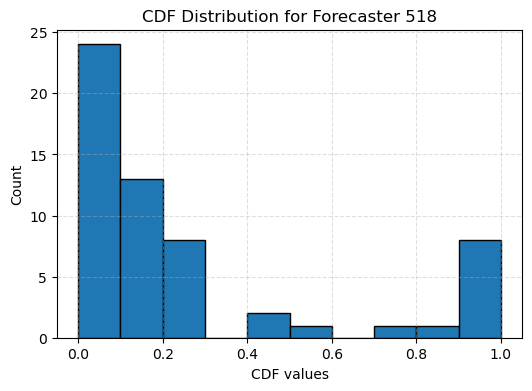

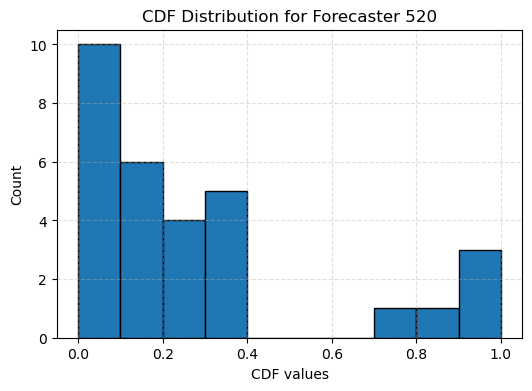

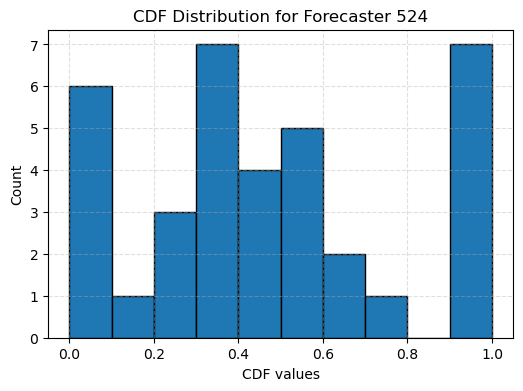

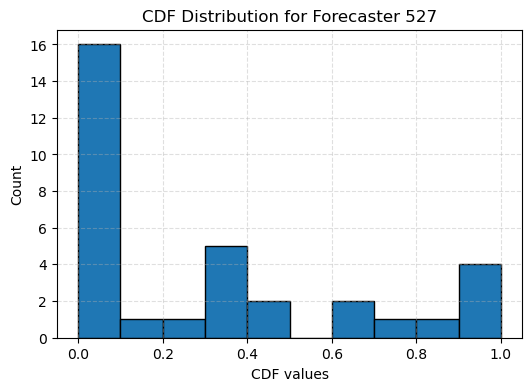

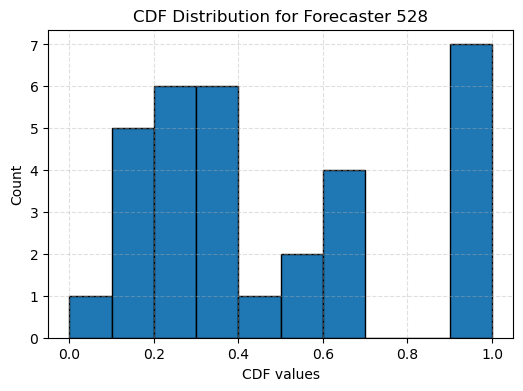

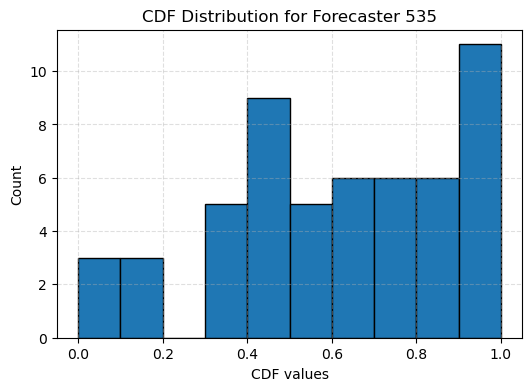

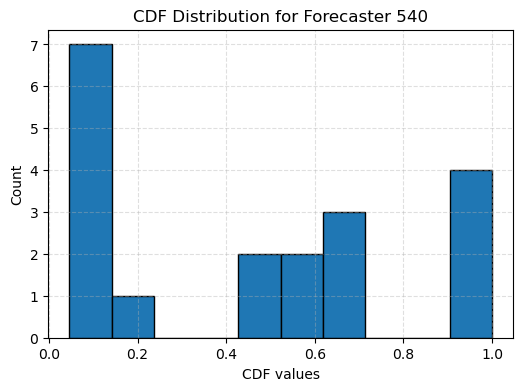

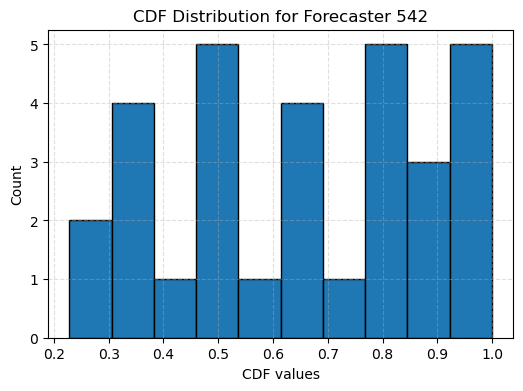

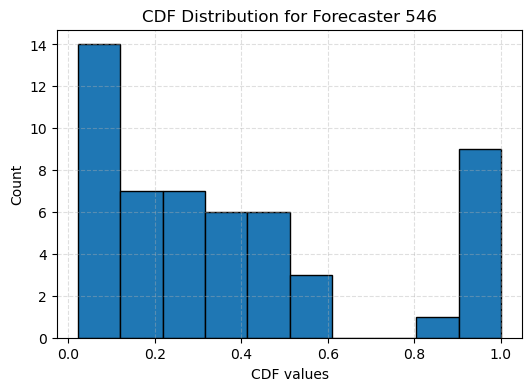

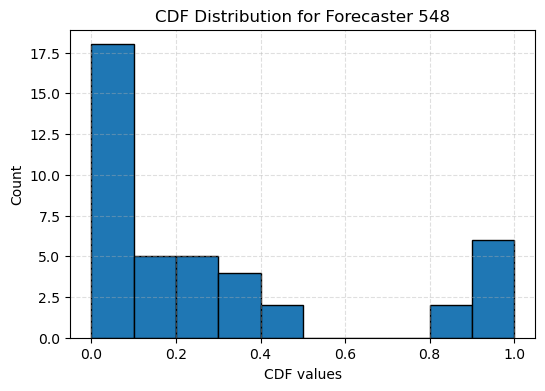

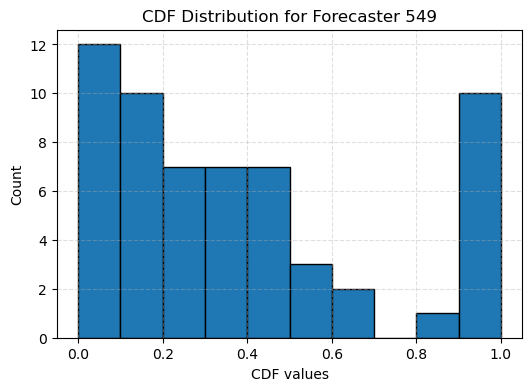

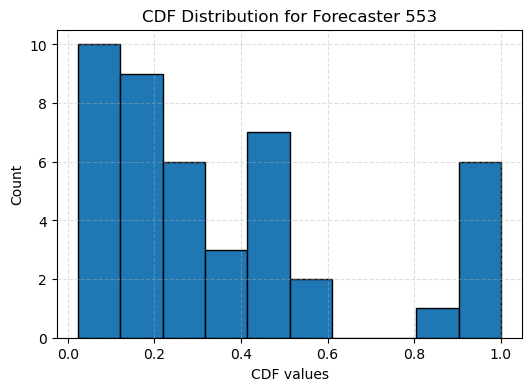

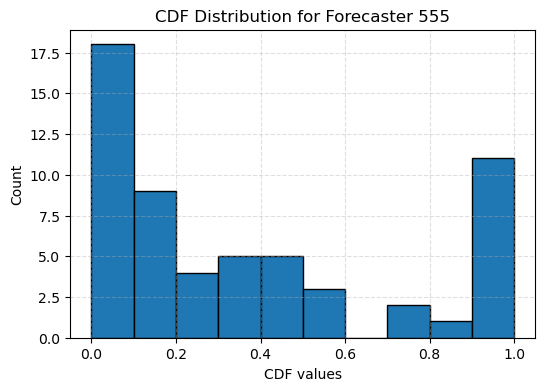

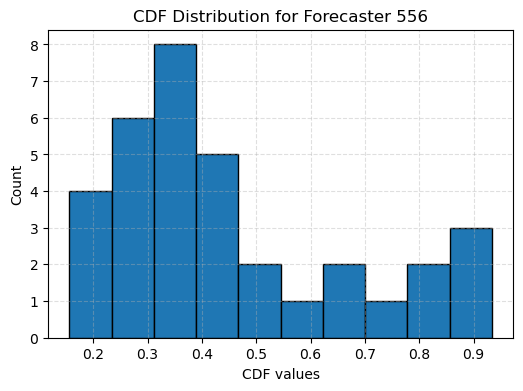

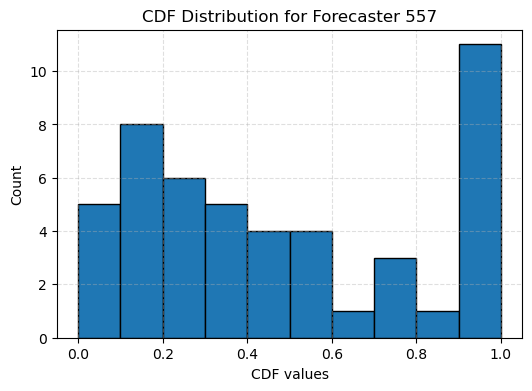

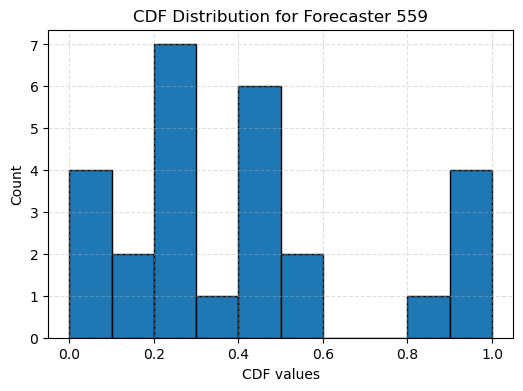

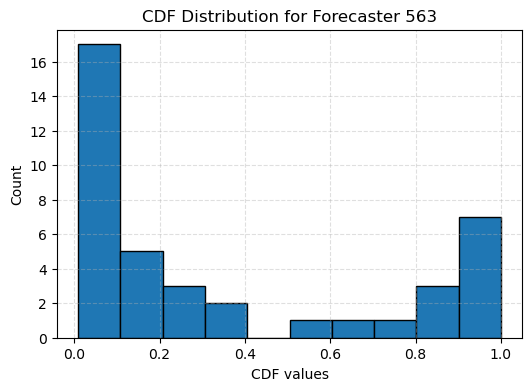

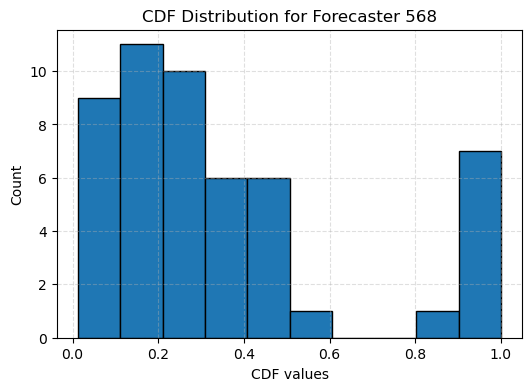

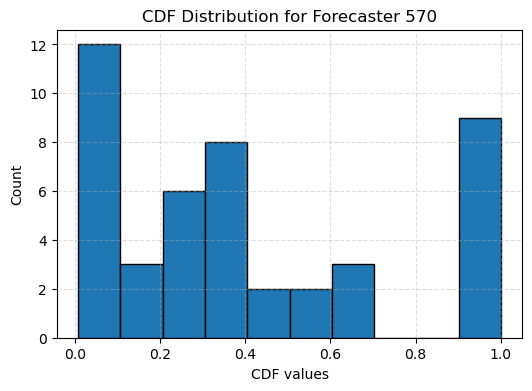

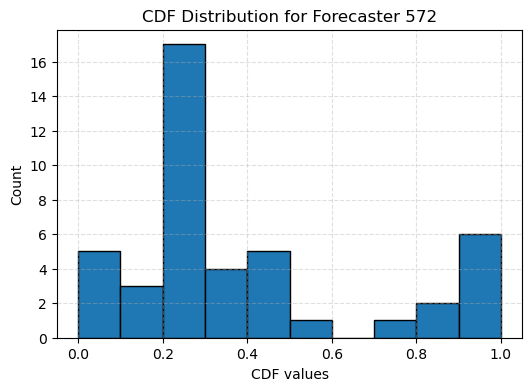

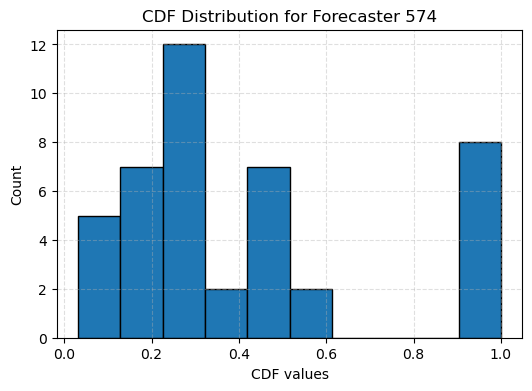

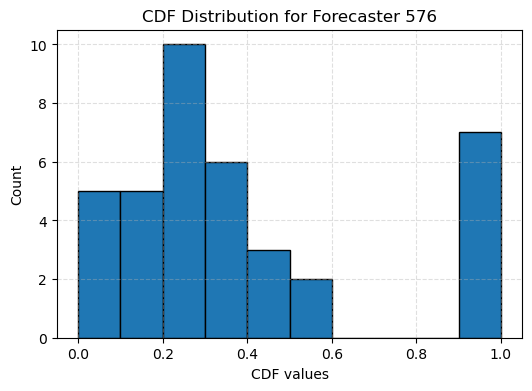

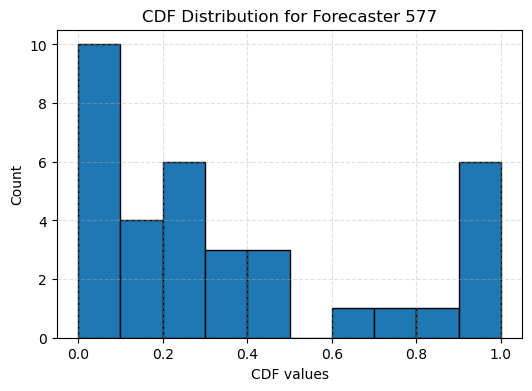

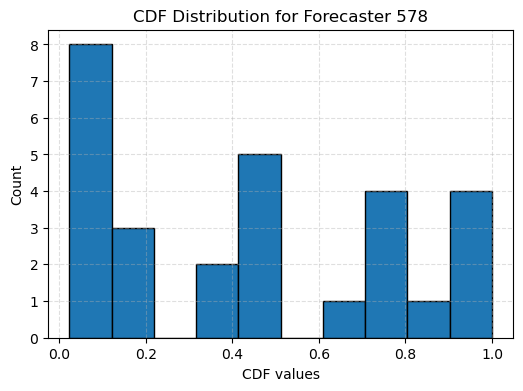

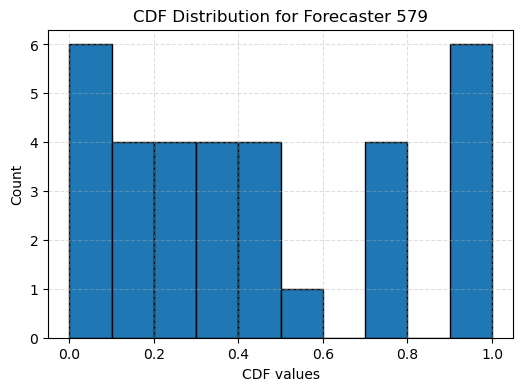

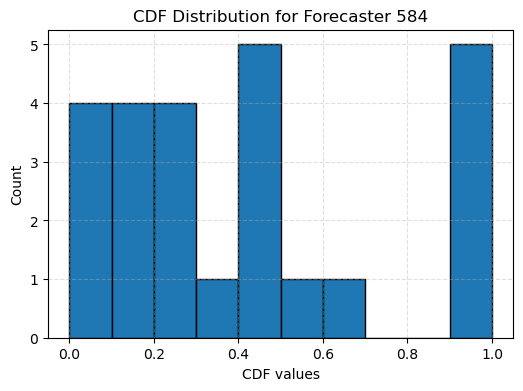

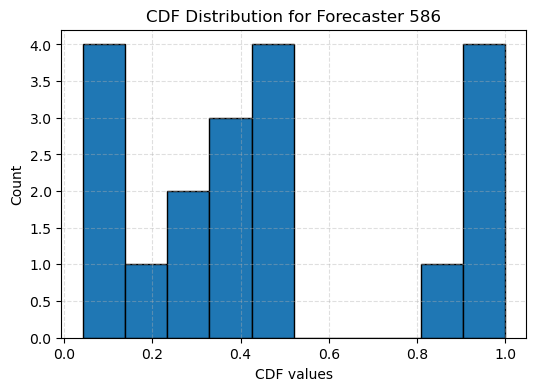

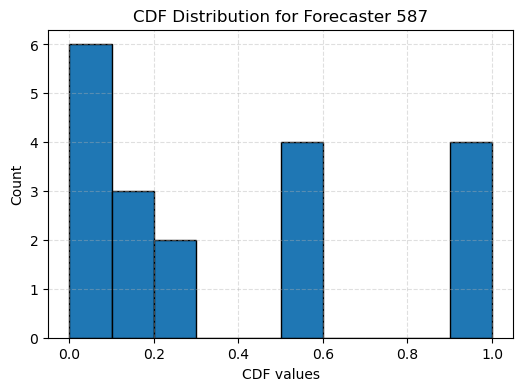

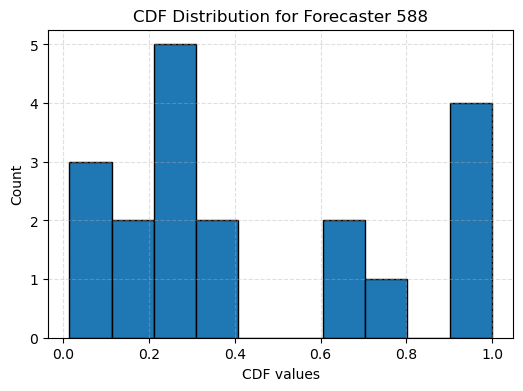

In [182]:
graph_spf1 = spf1.reset_index()
IDs = graph_spf1["ID"].unique()
for forecaster in IDs:
    # only rows for this forecaster
    rows = graph_spf1[graph_spf1["ID"] == forecaster]

    # CDF values for this forecaster
    forecaster_cdf = rows["CDF"]

    plt.figure(figsize=(6,4))
    plt.hist(forecaster_cdf, edgecolor="black")
    plt.grid(alpha=0.4, linestyle='--')
    plt.title("CDF Distribution for Forecaster " + str(forecaster))
    plt.xlabel("CDF values")
    plt.ylabel("Count")
    plt.show()


Q8.) Some of the CDF distributions looks similar to the one I found in part 1 but not exactly the same.

Q9.) Forecasters: 407, 421, 422, 433, 446, 463, 504, 510, 512, 524, 528, 540, 542, 546, 549, 553, 555, 556, 557, 559, 570, 574, 576, 579, 584, 586, 587, 588 seem rational.

In [81]:
graph_spf1

,ID,Date,YEAR,QUARTER,INDUSTRY,PRUNEMP11,PRUNEMP12,PRUNEMP13,PRUNEMP14,PRUNEMP15,PRUNEMP16,PRUNEMP17,PRUNEMP18,PRUNEMP19,PRUNEMP20,Next_Year,real_unemp,CDF
0,407,2009Q2,2009,2,2.0,0.0,0.0,5.0,70.0,15.0,10.0,0.0,0.0,0.0,0.0,2010,9.6,0.94
1,407,2009Q3,2009,3,2.0,0.0,0.0,0.0,5.0,70.0,25.0,0.0,0.0,0.0,0.0,2010,9.6,1.00
2,407,2009Q4,2009,4,2.0,0.0,5.0,85.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,2010,9.6,0.24
3,407,2010Q1,2010,1,2.0,0.0,0.0,0.0,0.0,40.0,60.0,0.0,0.0,0.0,0.0,2011,8.9,1.00
4,407,2010Q2,2010,2,2.0,0.0,0.0,0.0,15.0,20.0,60.0,5.0,0.0,0.0,0.0,2011,8.9,0.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,588,2022Q4,2022,4,1.0,0.0,0.0,0.0,0.0,0.0,20.0,55.0,20.0,5.0,0.0,2023,3.6,0.02
1732,588,2023Q1,2023,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,55.0,25.0,5.0,2024,4.0,0.30
1733,588,2023Q2,2023,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,55.0,25.0,5.0,2024,4.0,0.44
1734,588,2023Q3,2023,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,55.0,25.0,5.0,2024,4.0,0.32
